## FOMC Meeting Minutes Scraper and Analyzer

In [ ]:
# Install necessary libraries
!pip install requests beautifulsoup4 pdfplumber pandas nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 34.8 MB/s eta 0:00:00


In [ ]:
import requests
from bs4 import BeautifulSoup
import time
import re
import pdfplumber
import pandas as pd
from datetime import datetime
import os
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

### Helper Functions for Text Extraction and Date Parsing

In [ ]:
def extract_pdf_text(pdf_url, log_file='fomc_failed_urls.txt'):
    try:
        print(f"Downloading PDF from: {pdf_url}")
        response = requests.get(pdf_url, timeout=30)
        response.raise_for_status()

        # Save PDF to a temporary file
        temp_pdf_path = '/tmp/fomc_temp.pdf'
        with open(temp_pdf_path, 'wb') as f:
            f.write(response.content)

        full_text = ''
        with pdfplumber.open(temp_pdf_path) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    full_text += text + ' '

        # Clean extraction artifacts
        full_text = re.sub(r'\n+', ' ', full_text) # Replace multiple newlines with a single space
        full_text = re.sub(r'\s+', ' ', full_text).strip() # Replace multiple spaces with a single space
        full_text = re.sub(r'Page \d+ of \d+', '', full_text) # Remove page number artifacts (Page 1 of 15)

        os.remove(temp_pdf_path) # Clean up temporary file
        return full_text
    except requests.exceptions.RequestException as e:
        print(f"Network error downloading {pdf_url}: {e}")
        with open(log_file, 'a') as f:
            f.write(f"Failed to download PDF: {pdf_url} - {e}\n")
        return None
    except Exception as e: # Changed from pdfplumber.PDFError to a more general Exception
        print(f"PDF processing error for {pdf_url}: {e}")
        with open(log_file, 'a') as f:
            f.write(f"Failed to process PDF: {pdf_url} - {e}\n")
        return None
    except Exception as e:
        print(f"An unexpected error occurred for {pdf_url}: {e}")
        with open(log_file, 'a') as f:
            f.write(f"Unexpected error: {pdf_url} - {e}\n")
        return None

In [ ]:
def extract_html_text(html_url, log_file='fomc_failed_urls.txt'):
    try:
        print(f"Downloading HTML from: {html_url}")
        response = requests.get(html_url, timeout=30)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser')

        # Attempt to find the main content area
        # Common patterns: 'bodytext', 'main-content', 'article-content', 'content'
        content_div = soup.find('div', {'class': 'bodytext'}) or \
                      soup.find('div', {'id': 'main-content'}) or \
                      soup.find('article') or \
                      soup.find('div', {'id': 'content'})

        if content_div:
            # Remove script and style tags to clean content
            for script_or_style in content_div(['script', 'style']):
                script_or_style.decompose()
            text = content_div.get_text(separator=' ', strip=True)
        else:
            text = soup.get_text(separator=' ', strip=True)
            print(f"Warning: Could not find a specific content div for {html_url}. Extracting all text.")

        # Basic cleaning for HTML extracted text
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    except requests.exceptions.RequestException as e:
        print(f"Network error downloading {html_url}: {e}")
        with open(log_file, 'a') as f:
            f.write(f"Failed to download HTML: {html_url} - {e}\n")
        return None
    except Exception as e:
        print(f"An unexpected error occurred for {html_url}: {e}")
        with open(log_file, 'a') as f:
            f.write(f"Unexpected error: {html_url} - {e}\n")
        return None

In [ ]:
def parse_meeting_date(date_str):
    """Handle multiple FOMC date formats: 'January 25-26, 2022', 'June 14-15, 2022'"""
    # Remove the day range (e.g., '25-26') to get just the last day
    date_str_cleaned = re.sub(r'\d+-\d+', lambda m: m.group(0).split('-')[-1], date_str)

    # Patterns to try for parsing
    patterns = [
        r'(\w+ \d+), (\d{4})', # 'January 26, 2022'
    ]

    for pattern in patterns:
        match = re.search(pattern, date_str_cleaned)
        if match:
            # Reconstruct date string to be consistently 'Month Day, Year'
            parsed_date_str = f"{match.group(1)}, {match.group(2)}"
            try:
                return pd.to_datetime(parsed_date_str, format='%B %d, %Y')
            except ValueError:
                continue # Try next pattern if this one fails

    print(f"Could not parse date: {date_str}")
    return None

In [ ]:
import requests
from bs4 import BeautifulSoup
import time
import re
import pdfplumber
import pandas as pd
from datetime import datetime
import os
from collections import Counter
import nltk
from nltk.corpus import stopwords
from urllib.parse import urljoin # Import urljoin from urllib.parse


# Existing helper functions (extract_pdf_text, extract_html_text, parse_meeting_date) would be here if not in separate cells.

def clean_introductory_text(text):
    """Removes introductory text (like attendee lists) from FOMC minutes."""
    # Patterns that reliably mark the start of the *substantive discussion*
    # These should typically appear *after* the attendee lists.
    start_of_discussion_patterns = [
        r'Developments in Financial Markets and Open Market Operations',
        r'Staff Review of the Economic Situation',
        r'Staff Review of the Financial Situation',
        r'In their discussion of the economic situation',
        r'In their discussion of the financial situation',
        r'Committee Policy Action',
        r'Discussion of Monetary Policy Strategy and Tools',
        r'Developments in financial markets and the federal debt ceiling',
        r"Participants' Discussion of Current Economic Conditions and the Economic Outlook",
        r"Participants' Discussion",
        r"The Committee's Discussion",
        r"The Committee considered",
        r"Staff Presentation",
        r"Staff Briefing",
        r"Financial Developments",
        r"Economic Developments",
        r"Review of Financial Developments",
        r"Review of Economic Developments",
        r'A joint meeting of the Federal Open Market Committee and the Board of Governors of the Federal Reserve System was held',
        r'The Federal Open Market Committee met in Washington, D.C., on',
        r'The meeting convened in Washington, D.C., on'
    ]

    # Patterns that mark the general start of the meeting minutes,
    # but might sometimes still include attendee lists depending on placement.
    general_intro_patterns = [
        r'The Federal Reserve Board and the Federal Open Market Committee met',
        r'The Federal Open Market Committee met on',
        r'A meeting of the Federal Open Market Committee was held',
        r'The meeting began at \d{1,2}:\d{2} [ap]\.m\. on',
        r'The meeting convened at \d{1,2}:\d{2} [ap]\.m\. on',
        r'The Manager of the System Open Market Account reported',
        r'The Manager of the System Open Market Account presented',
    ]

    # First, try to find the first occurrence of any substantive discussion pattern
    for pattern in start_of_discussion_patterns:
        match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
        if match:
            return text[match.start():].strip()

    # If no specific discussion start pattern is found, try more general introductory patterns
    for pattern in general_intro_patterns:
        match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
        if match:
            return text[match.start():].strip()

    # Fallback heuristic: remove content before the first main paragraph break if it's early
    if len(text) > 2000: # Only apply if text is long enough to have an intro
        first_paragraph_break = text.find('  ') # Find two spaces, often indicates new paragraph
        if first_paragraph_break != -1 and first_paragraph_break < 1000: # If break is relatively early
            return text[first_paragraph_break:].strip()

    return text # Return original if no pattern found or heuristic not met

def scrape_fomc_minutes(base_url='https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm',
                          years_to_scrape=range(2022, 2026),
                          crawl_delay=1,
                          log_file='fomc_failed_urls.txt'):

    all_minutes_data = []

    print(f"Navigating to {base_url} to find meeting minutes links...")
    try:
        response = requests.get(base_url, timeout=30)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser')
    except requests.exceptions.RequestException as e:
        print(f"Error accessing the main calendar page: {e}")
        return pd.DataFrame()

    content_div = soup.find('div', id='content') or soup.find('div', id='main-content')
    if not content_div:
        content_div = soup.body

    # Find all links on the page that might be minutes
    # We look for links where href contains 'fomcminutes' OR link text contains 'minutes'
    potential_minutes_links = []
    for link in content_div.find_all('a', href=True):
        href = link['href'].lower()
        link_text = link.get_text(strip=True).lower()
        # Filter to include links with 'fomcminutes' in href or 'minutes' in text (excluding 'statement' to avoid duplicates)
        if 'fomcminutes' in href or ('minutes' in link_text and 'statement' not in link_text):
            potential_minutes_links.append(link)

    if not potential_minutes_links:
        print("No potential minutes links found based on 'fomcminutes' in href or 'minutes' in text.")
        return pd.DataFrame()

    print(f"Found {len(potential_minutes_links)} potential minutes links.")

    for link in potential_minutes_links:
        href = link['href']
        full_url = urljoin(base_url, href) # Corrected: use urljoin from urllib.parse
        link_type = 'pdf' if '.pdf' in href.lower() else 'html'

        meeting_date_str = None
        # Try to find the date string in the surrounding context of the link
        # Look in the immediate parent, grandparent, or preceding siblings, or direct text children of parent
        search_elements = [link.parent, link.parent.parent, link.previous_sibling, link.find_previous_sibling()]
        search_elements = [el for el in search_elements if el] # Filter out None

        # Add direct text content of the parent element as a search area
        if link.parent and hasattr(link.parent, 'children'):
            for child in link.parent.children:
                if isinstance(child, str) and child.strip():
                    search_elements.insert(0, child.strip()) # Prioritize direct text content

        for el in search_elements:
            text_to_search = ''
            if isinstance(el, str): # Direct text node already extracted
                text_to_search = el
            elif hasattr(el, 'get_text'):
                text_to_search = el.get_text(separator=' ', strip=True)

            if text_to_search:
                date_match = re.search(r'(\w+ \d+(?:-\d+)?), (\d{4})', text_to_search)
                if date_match:
                    meeting_date_str = date_match.group(0)
                    break

        if meeting_date_str:
            parsed_date = parse_meeting_date(meeting_date_str)
            if parsed_date and parsed_date.year in years_to_scrape:
                all_minutes_data.append({
                    'year': parsed_date.year,
                    'meeting_date_str': meeting_date_str,
                    'meeting_date': parsed_date,
                    'link_type': link_type,
                    'url': full_url
                })
            elif not parsed_date:
                print(f"Failed to parse date '{meeting_date_str}' for link: {full_url}")
            elif parsed_date.year not in years_to_scrape:
                # This means we found a link, parsed a date, but it's outside the target years.
                # This is okay, just skip it.
                pass
        else:
            print(f"Could not find meeting date for link: {full_url}")

    df = pd.DataFrame(all_minutes_data)
    if df.empty:
        print("No minutes found for the specified years after processing all potential links.")
        return df

    # Ensure uniqueness of links and sort by date
    df = df.drop_duplicates(subset=['url']).sort_values(by='meeting_date').reset_index(drop=True)

    print(f"Found {len(df)} unique meeting minutes links for years {min(years_to_scrape)}-{max(years_to_scrape)}.")

    extracted_texts = []
    for index, row in df.iterrows():
        print(f"[{index+1}/{len(df)}] Extracting text for {row['meeting_date_str']} ({row['link_type'].upper()})... ভেবে")
        if row['link_type'] == 'pdf':
            text = extract_pdf_text(row['url'], log_file=log_file)
        else: # html
            text = extract_html_text(row['url'], log_file=log_file)

        if text: # Apply cleaning only if text was successfully extracted
            text = clean_introductory_text(text)

        extracted_texts.append(text)
        time.sleep(crawl_delay)

    df['text_content'] = extracted_texts
    df['month'] = df['meeting_date'].dt.strftime('%B %Y')

    df_cleaned = df.dropna(subset=['text_content']).reset_index(drop=True)
    print(f"Successfully extracted text from {len(df_cleaned)} out of {len(df)} links.")

    return df_cleaned

# Execute the scraper
fomc_df = scrape_fomc_minutes()
print("\n--- Scraping Complete ---")
print(f"Total records collected: {len(fomc_df)}")
if not fomc_df.empty:
    print(fomc_df.head())
    print(fomc_df.info())

Navigating to https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm to find meeting minutes links...
Found 84 potential minutes links.
Found 66 unique meeting minutes links for years 2022-2025.
[1/66] Extracting text for January 05, 2022 (HTML)... ভেবে
[2/66] Extracting text for January 05, 2022 (PDF)... ভেবে
[3/66] Extracting text for February 16, 2022 (PDF)... ভেবে
[4/66] Extracting text for February 16, 2022 (HTML)... ভেবে
[5/66] Extracting text for April 06, 2022 (PDF)... ভেবে
[6/66] Extracting text for April 06, 2022 (HTML)... ভেবে
[7/66] Extracting text for May 25, 2022 (PDF)... ভেবে
[8/66] Extracting text for May 25, 2022 (HTML)... ভেবে
[9/66] Extracting text for July 06, 2022 (PDF)... ভেবে
[10/66] Extracting text for July 06, 2022 (HTML)... ভেবে
[11/66] Extracting text for August 17, 2022 (PDF)... ভেবে
[12/66] Extracting text for August 17, 2022 (HTML)... ভেবে
[13/66] Extracting text for October 12, 2022 (PDF)... ভেবে
[14/66] Extracting text for October 12, 2022 (HTML

In [ ]:
print("\n--- Filtering to 8 unique meetings per year ---")
# Drop duplicates based on 'meeting_date' to keep only one entry per meeting
fomc_df_unique_meetings = fomc_df.drop_duplicates(subset=['meeting_date']).reset_index(drop=True)

# Re-check meetings per year after filtering
meetings_per_year_filtered = fomc_df_unique_meetings['meeting_date'].dt.year.value_counts().sort_index()
print("Meetings per Year (after filtering for unique dates):")
print(meetings_per_year_filtered.to_frame(name='Count'))

fomc_df = fomc_df_unique_meetings.copy() # Update fomc_df to the filtered version


--- Filtering to 8 unique meetings per year ---
Meetings per Year (after filtering for unique dates):
              Count
meeting_date       
2022              8
2023              8
2024              8
2025              9


In [ ]:
print("\n--- Current FOMC DataFrame (first 5 rows) ---")
display(fomc_df.head())

print("\n--- FOMC DataFrame Info ---")
fomc_df.info()


--- Current FOMC DataFrame (first 5 rows) ---


,year,meeting_date_str,meeting_date,link_type,url,text_content,month
0,2022,"January 05, 2022",2022-01-05,html,https://www.federalreserve.gov/monetarypolicy/...,Developments in Financial Markets and Open Mar...,January 2022
1,2022,"February 16, 2022",2022-02-16,pdf,https://www.federalreserve.gov/monetarypolicy/...,Staff Review of the Economic Situation was clo...,February 2022
2,2022,"April 06, 2022",2022-04-06,pdf,https://www.federalreserve.gov/monetarypolicy/...,Staff Review of the Economic Situation Availab...,April 2022
3,2022,"May 25, 2022",2022-05-25,pdf,https://www.federalreserve.gov/monetarypolicy/...,Staff Review of the Economic Situation impleme...,May 2022
4,2022,"July 06, 2022",2022-07-06,pdf,https://www.federalreserve.gov/monetarypolicy/...,Staff Review of the Economic Situation term in...,July 2022



--- FOMC DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   year              33 non-null     int64         
 1   meeting_date_str  33 non-null     object        
 2   meeting_date      33 non-null     datetime64[ns]
 3   link_type         33 non-null     object        
 4   url               33 non-null     object        
 5   text_content      33 non-null     object        
 6   month             33 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 1.9+ KB


In [ ]:
import os
from google.colab import files

# Define the filename for the CSV
csv_filename = 'fomc_meeting_minutes1.csv'

# Save the DataFrame to a CSV file
fomc_df.to_csv(csv_filename, index=False)

print(f"DataFrame saved to '{csv_filename}' in the Colab environment.")

# Trigger the download to the user's local machine
files.download(csv_filename)

print("Download initiated. Please check your browser's download folder.")

DataFrame saved to 'fomc_meeting_minutes1.csv' in the Colab environment.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated. Please check your browser's download folder.


### Data Validation and Analysis


--- 1. Word Count Distribution ---


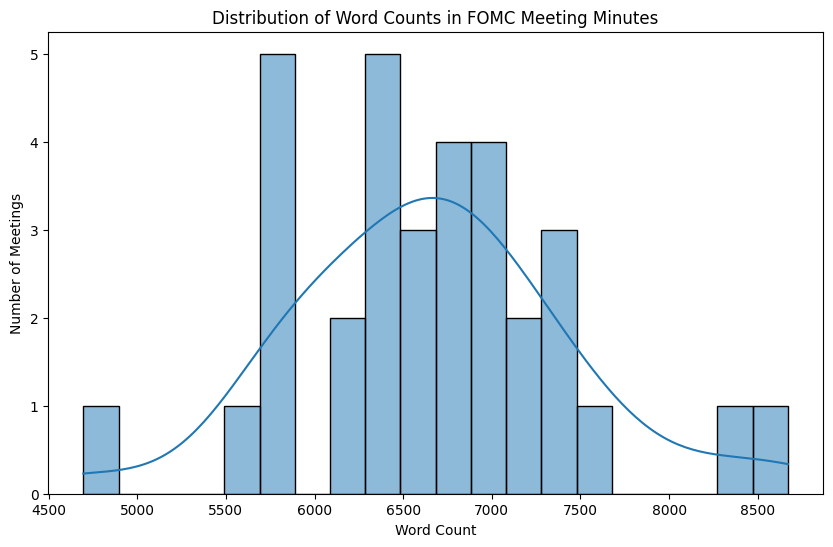


All meetings have a word count of 3,000 or more.
Expected range: 8,000-15,000 words. Current range: 4696-8670 words.


In [ ]:
# 1. Word Count Distribution
print("\n--- 1. Word Count Distribution ---")
fomc_df['word_count'] = fomc_df['text_content'].apply(lambda x: len(x.split()))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(fomc_df['word_count'], bins=20, kde=True)
plt.title('Distribution of Word Counts in FOMC Meeting Minutes')
plt.xlabel('Word Count')
plt.ylabel('Number of Meetings')
plt.show()

# Flag meetings below 3,000 words
short_meetings = fomc_df[fomc_df['word_count'] < 3000]
if not short_meetings.empty:
    print("\nMeetings with word count below 3,000:")
    print(short_meetings[['meeting_date_str', 'word_count']])
else:
    print("\nAll meetings have a word count of 3,000 or more.")

print(f"Expected range: 8,000-15,000 words. Current range: {fomc_df['word_count'].min()}-{fomc_df['word_count'].max()} words.")

In [ ]:
# 2. Temporal Coverage Check
print("\n--- 2. Temporal Coverage Check ---")
meetings_per_year = fomc_df['meeting_date'].dt.year.value_counts().sort_index()
print("Meetings per Year:")
print(meetings_per_year.to_frame(name='Count'))

# Check for 8 meetings per year for 2022-2024
for year in range(2022, 2025):
    count = meetings_per_year.get(year, 0)
    if count != 8:
        print(f"Warning: Year {year} has {count} meetings, expected 8.")
    else:
        print(f"Year {year}: {count} meetings (as expected).")

# 2025 may be partial
if 2025 in meetings_per_year:
    print(f"Year 2025: {meetings_per_year[2025]} meetings (partial year expected).")


--- 2. Temporal Coverage Check ---
Meetings per Year:
              Count
meeting_date       
2022              8
2023              8
2024              8
2025              9
Year 2022: 8 meetings (as expected).
Year 2023: 8 meetings (as expected).
Year 2024: 8 meetings (as expected).
Year 2025: 9 meetings (partial year expected).


In [ ]:
# 3. Most Frequent Terms by Year (Top-20 unigrams after stopword removal)
print("\n--- 3. Most Frequent Terms by Year ---")
stop_words = set(stopwords.words('english'))

def get_top_n_words(text, n=None):
    words = re.findall(r'\b\w+\b', text.lower())
    words = [word for word in words if word.isalpha() and word not in stop_words]
    word_counts = Counter(words)
    return word_counts.most_common(n)

for year in sorted(fomc_df['meeting_date'].dt.year.unique()):
    print(f"\nTop 20 unigrams for {year}:")
    year_text = " ".join(fomc_df[fomc_df['meeting_date'].dt.year == year]['text_content'].tolist())
    top_words = get_top_n_words(year_text, 20)
    print(top_words)

    # Confirm 'inflation' dominates 2022, 'disinflation' appears in 2023
    if year == 2022:
        inflation_present = any(word == 'inflation' for word, count in top_words)
        print(f"'inflation' among top words in 2022: {inflation_present}")
    elif year == 2023:
        disinflation_present = any(word == 'disinflation' for word, count in top_words)
        print(f"'disinflation' among top words in 2023: {disinflation_present}")


--- 3. Most Frequent Terms by Year ---

Top 20 unigrams for 2022:
[('inflation', 550), ('participants', 515), ('policy', 357), ('rate', 344), ('committee', 311), ('would', 275), ('market', 272), ('federal', 269), ('economic', 265), ('remained', 244), ('percent', 228), ('continued', 197), ('labor', 196), ('supply', 184), ('monetary', 179), ('credit', 179), ('reserve', 170), ('noted', 169), ('growth', 167), ('price', 167)]
'inflation' among top words in 2022: True

Top 20 unigrams for 2023:
[('inflation', 661), ('participants', 547), ('rate', 362), ('policy', 358), ('economic', 322), ('market', 314), ('remained', 302), ('committee', 295), ('percent', 291), ('federal', 261), ('would', 223), ('credit', 221), ('conditions', 201), ('monetary', 195), ('noted', 187), ('labor', 177), ('year', 176), ('rates', 174), ('growth', 173), ('activity', 169)]
'disinflation' among top words in 2023: False

Top 20 unigrams for 2024:
[('participants', 523), ('inflation', 509), ('rate', 377), ('committee', 

In [ ]:
# 4. Date Column Verification
print("\n--- 4. Date Column Verification ---")
print(f"df['meeting_date'].dtype: {fomc_df['meeting_date'].dtype}")
print("Expected: datetime64[ns]")

print("\ndf['month'].head(12):")
print(fomc_df['month'].head(12))
print("Expected format: 'Month YYYY'")


--- 4. Date Column Verification ---
df['meeting_date'].dtype: datetime64[ns]
Expected: datetime64[ns]

df['month'].head(12):
0      January 2022
1     February 2022
2        April 2022
3          May 2022
4         July 2022
5       August 2022
6      October 2022
7     November 2022
8      January 2023
9     February 2023
10       April 2023
11         May 2023
Name: month, dtype: object
Expected format: 'Month YYYY'
